In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.6/549.6 kB 12.9 MB/s eta 0:00:00


Real parameter: b = 3, c = 2
Real initial condition: 0 0


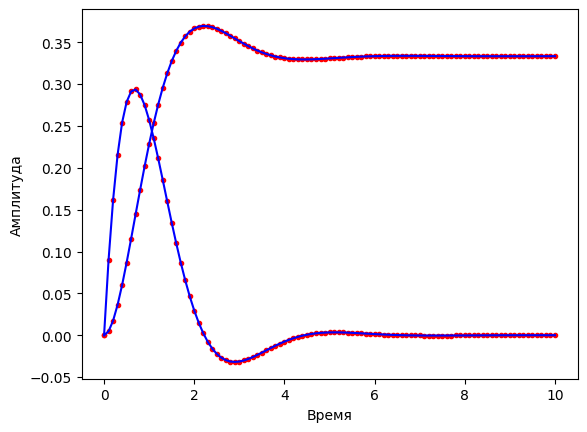

Estimated parameter: a=3.0000000017648834, b=1.9999999036760732
Estimated initial condition: [ 2.20641385e-08 -3.88459525e-08]


In [ ]:
import pylab as pp
import numpy as np
from scipy import integrate, optimize
from scipy.integrate import odeint

# Глобальные переменные
x_data = None
y_data = None
n_observed = None
f = None
y0_len = None
c = None

def my_ls_func(x, teta):
    """
    Определение функции, возвращающей непосредственно решение системы ДУ
    в процессе оценки параметров
    x заданные (временные) точки, где известно решение
    (экспериментальные данные)
    teta -- массив с текущим значением оцениваемых параметров.
    Первые self._y0_len элементов -- начальные условия,
    остальные -- параметры ДУ
    """
    # Для передачи функуии используем ламбда-выражение с подставленными
    # параметрами
    # Вычислим значения дифференциального уравления в точках "x"
    r = odeint(lambda y, t: f(y, t, teta[y0_len:]), teta[:y0_len], x)
    # Возвращаем только наблюдаемые переменные
    return r[:, :n_observed]

def f_resid(p):
    """
    Функция для передачи в optimize.leastsq
    Функция вычисляет вектор ошибок между решением системы ДУ
    с текущими значениями параметров и экспериментальными значениями.
    Функция получает вектор параметров системы (включая начальные условия ДУ).
    При дальнейших вычислениях значения, возвращаемые этой функцией,
    будут возведены в квадрат и просуммированы
    """
    delta = y_data - my_ls_func(x_data, p)
    return delta.flatten()  # Преобразуем в одномерный массив

def estimate(y0, guess):
    """
    Произвести оценку параметров дифференциального уравнения с заданными
    начальными значениями параметров:
        y0 -- начальные условия ДУ
        guess -- начальные значения параметров системы ДУ
    """
    global y0_len, c
    # Сохраняем число начальных условий
    y0_len = len(y0)

    # Создаем вектор оцениваемых параметров,
    # включающий в себя начальные условия
    est_values = np.concatenate((y0, guess))

    # Решаем оптимизационную задачу - решение в переменной c
    c, _ = optimize.leastsq(f_resid, est_values)
    # В возвращаемом значении разделяем начальные условия и параметры
    return c[y0_len:], c[:y0_len]

def calcODE(args, y0, x0=0, xEnd=10, nt=101):
    """
    Служебная функция для решения ДУ
    """
    t = np.linspace(x0, xEnd, nt)
    sol = odeint(f, y0, t, args)
    return sol, t

def plot_result():
    """
    Строим графическое предстваление результутов оценки параметров
    """
    if c is None:
        print("Parameter is not estimated.")
        return

    sol, t = calcODE((c[y0_len:],), c[:y0_len], min(x_data), max(x_data))
    # Строим экспериментальные данные, как красные точки,
    # а результаты моделирования, как синюю линию
    pp.plot(x_data, y_data, '.r', t, sol, '-b')
    pp.xlabel('Время')
    pp.ylabel("Амплитуда")
    pp.show()

def system_equations(y, t, k):
    x1, x2 = y
    a = k[0]
    b = k[1]
    # u(t) = 1 => u'(t) = 0
    dydt = [x2, -a*x1 - b*x2 + 1]
    return dydt

def calcSystem(args, y0, dy0, ts=10, nt=101):
    y0 = [y0, dy0]
    t = np.linspace(0, ts, nt)
    sol = odeint(system_equations, y0, t, args)
    return sol, t

# Зададим истинные значения параметров системы
a = 3
b = 2

args = ([a, b], )
y0_true = 0
dy0_true = 0
print("Real parameter: b = {}, c = {}".format(a, b))
print("Real initial condition: {} {}".format(y0_true, dy0_true))

sol, t = calcSystem(args, y0_true, dy0_true)

# Исходными данными, передаваемыми при создании экземпляра класса оценки параметров являются:
# Функция f, реализующая вычисление ДУ
# Массив экспериментальных данных (x_data, y_data)
x_data = t
y_data = sol
n_observed = y_data.shape[1]
f = system_equations

guess = [5, 1]  # Начальные значения для параметров системы
y0 = [0, 0]  # Стартовые начальные значения для системы ДУ

est_par, est_init = estimate(y0, guess)

# Построим графики результатов оценки параметров
plot_result()

print("Estimated parameter: a={}, b={}".format(est_par[0], est_par[1]))
print("Estimated initial condition: {}".format(est_init))
